In [ ]:
%run /content/AIFFEL_final_project_peekabook/research/src/tools/tools.ipynb

## 라이브러리 및 API Key 세팅

In [ ]:
!pip install -qU langchain-core langchain-openai langgraph langchain langchain-naver

In [ ]:
# 라이브러리 설치 (필요시)
# !pip install -qU langchain-openai langgraph

import os
import requests
from google.colab import userdata
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

# API 키 세팅
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["CLOVASTUDIO_API_KEY"] = userdata.get('CLOVASTUDIO_API_KEY')

# 도서관 정보나루 API
DATA4LIBRARY_KEY = userdata.get('DATA4LIBRARY_KEY')

## Tool Calling Agent 초기화

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_naver import ChatClovaX


# 1. 툴 리스트 업데이트 (수정된 get_book_isbn 포함)
tools = [search_library, get_popular_books, check_book_availability, get_trending_books, get_book_recommendations, get_book_isbn]

# 2. 에이전트의 '두뇌' 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
# llm = ChatClovaX(model="HCX-005", temperature=0)

# 3. 🚨 [신규 추가] 에이전트의 행동 지침 및 출력 템플릿(시스템 프롬프트) 정의
system_prompt = """당신은 도서관 책 추천 큐레이터입니다.

[출력 형식 - 반드시 지킬 것]
추천 도서마다 아래 형식으로 작성하세요.

---
📚 {책 제목} | {저자}
![책 제목](이미지URL)

✏️ 추천 이유
(전달받은 추천 이유를 그대로 작성)

📍 대출 가능 여부
- (도구 호출로 얻은 실제 도서관 이름): (대출 가능) or (대출 불가) or (미소장)
---

[주의사항]
- 추천 도서 목록의 3권을 반드시 모두 위 형식으로 출력하세요. 예외는 없습니다.
- 대출 가능 여부와 관계없이 3권 전부 출력하세요.
- 항목에는 search_library 도구로 조회한 실제 도서관 이름을 그대로 사용하세요.
- 도구 호출에 실패하거나 정보를 확인할 수 없는 경우 "확인 불가"로 표시하고 출력 형식은 반드시 유지하세요.
- 이미지 URL을 가져오지 못한 경우 이미지 라인은 생략하세요.
- 책을 제거하거나 다른 책으로 대체하는 것은 절대 금지입니다.
- 대출 불가를 이유로 추가 멘트, 대안 제시, 도서관 방문 권유 등 불필요한 내용을 덧붙이지 마세요.
- ISBN, 이미지 URL, 대출 정보는 반드시 도구 호출 결과만 사용하세요. 절대 지어내지 마세요.
"""

# 4. LangGraph 에이전트(ReAct 에이전트) 생성 (state_modifier에 프롬프트 주입)
agent_executor = create_react_agent(
    llm,
    tools,
    prompt=system_prompt  # 🚨 state_modifier 대신 prompt를 사용합니다!
)

✅ 다정하고 시각적인 큐레이터 에이전트 세팅 완료!


/tmp/ipykernel_4289/155779788.py:25: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


In [ ]:
# from langchain_core.messages import HumanMessage

# result = agent_executor.invoke({
#     "messages": [HumanMessage(content="강남구에서 소년이 온다 빌릴 수 있어?")]
# })

# print(result["messages"][-1].content)


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [도서관 목록 조회 API 통신 로그]
👉 실제 호출된 URL: http://data4library.kr/api/libSrch?authKey=%0916424b20e4393e27541144ae9873e2dd63a08d7a4eb6b73942c93b4d54f4241f&region=11&dtl_region=11230&pageSize=3&format=json
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [대출 가능 여부 조회 API 통신 로그]
👉 실제 호출된 URL: http://data4library.kr/api/bookExist?authKey=%0916424b20e4393e27541144ae9873e2dd63a08d7a4eb6b73942c93b4d54f4241f&libCode=111533&isbn13=9788936434120&format=json
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [대출 가능 여부 조회 API 통신 로그]
👉 실제 호출된 URL: http://data4library.kr/api/bookExist?authKey=%0916424b20e4393e27541144ae9873e2dd63a08d7a4eb6b73942c93b4d54f4241f&libCode=111526&isbn13=9788936434120&format=json
▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲▲


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
📡 [대출 가능 여부 조회 API 통신 로그]
👉 실제 호출된 

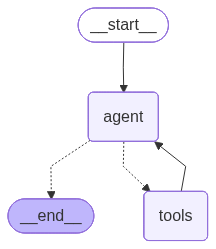

In [ ]:
# from IPython.display import Image, display

# display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage


def api_tool_calling_node(state: GraphState) -> dict:
    recommendations = state.get("recommendations", [])
    summary = state.get("summary", "")
    district = "강남구"   # 추후 중간에 LLM 노드를 추가해서 지역 정보를 사용자로부터 얻는 게 좋을듯

    # recommendations가 문자열로 넘어온 경우 대비
    if isinstance(recommendations, str):
        rec_text = recommendations
    else:
        rec_text = "\n".join([
            f"- 제목: {r['title']}, 저자: {r['author']}, ISBN: {r['isbn']}, 추천 이유: {r['reason']}"
            for r in recommendations
        ])

    query = f"""
아래 추천 도서 3권의 표지 이미지와 {district} 도서관 대출 가능 여부를 확인해서 최종 추천 답변을 만들어줘.

[추천 도서]
{rec_text}

[사용자 프로파일]
{summary}
"""

    result = agent_executor.invoke({
        "messages": [HumanMessage(content=query)]
    })

    return {
        "messages": [result["messages"][-1]],
    }